In [2]:
import os
import sys
from pathlib import Path
import importlib
import torch

In [3]:
#@title Mount Goole Drive

root_path = "/content/drive/MyDrive/MSc/Flood-Mapping"  #@param {type:"string", multiline:true}


mount_drive = True  #@param {type:"boolean"}

clone_repo = False  #@param {type:"boolean"}

if clone_repo and mount_drive:

    from google.colab import drive
    drive.mount("/content/drive")

    root_path = os.path.join(root_path, "Flood-Mapping")

    !git clone https://github.com/TAX2310/Flood-Mapping.git $root_path

    sys.path.append(os.path.join(root_path))

    from src.config import S2_CFG
    cfg = S2_CFG()

    cfg.ROOT = Path(root_path)

elif not clone_repo and mount_drive:
    from google.colab import drive
    drive.mount("/content/drive")

    sys.path.append(os.path.join(root_path))

    from src.config import S2_CFG
    cfg = S2_CFG()

    cfg.ROOT = Path(root_path)

elif clone_repo and not mount_drive:
    root_path = "Flood-Mapping"

    !git clone https://github.com/TAX2310/Flood-Mapping.git

    sys.path.append(root_path)

    from src.config import S2_CFG
    cfg = S2_CFG()

    cfg.ROOT = Path(root_path)

else:
    from src.config import S2_CFG
    cfg = S2_CFG()

    sys.path.append(os.path.join(cfg.ROOT))

cfg.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

Mounted at /content/drive


In [4]:
requirements = cfg.ROOT / "requirements.txt"
!pip install -r {requirements}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.3 MB/s eta 0:00:00


In [5]:
import src.train.training as training
import src.test.testing as testing
import src.util.io as io
import src.util.plotting as plot

In [ ]:
learning_rates = [1e-3, 1e-4]
batch_sizes = [32, 64]
weight_decays = [0.0, 1e-5]
dropout_rates = [0.0, 0.2]

In [ ]:
for learning_rate in learning_rates:
    for batch_size in batch_sizes:
        for weight_decay in weight_decays:
            for dropout_rate in dropout_rates:
                cfg.LR = learning_rate
                cfg.BATCH_SIZE = batch_size
                cfg.WEIGHT_DECAY = weight_decay
                cfg.DROPOUT_RATE = dropout_rate
                training.train_from_file(cfg, num_workers=8)

Found 16 model subdirectories in /content/drive/MyDrive/MSc/Flood-Mapping/experiments/STURM-fusion-24/Sentinel2_Optical


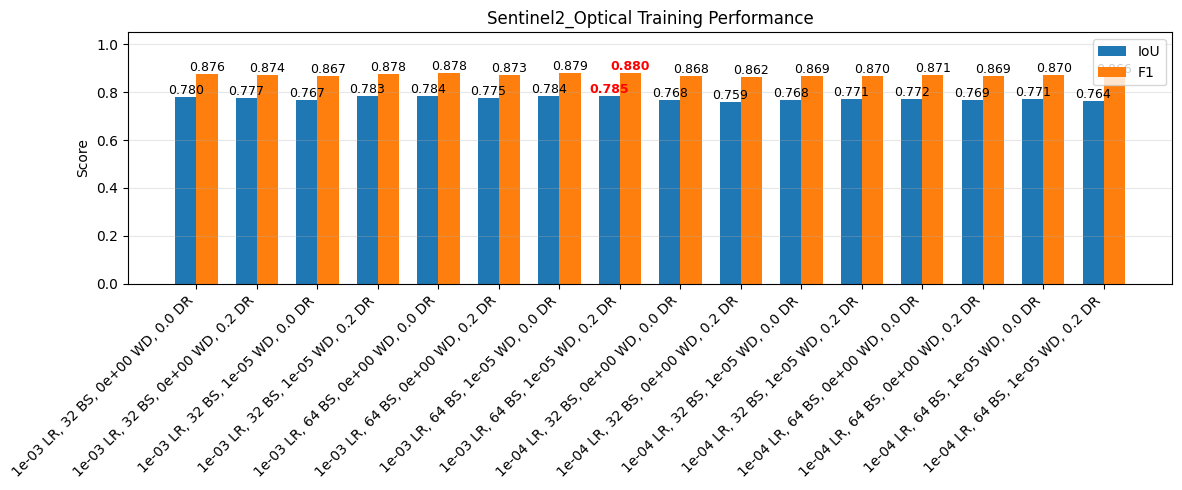

In [5]:
plot.view_f1_iou_bar(cfg)

In [6]:
plot.view_training_metrics(cfg)

Dropdown(description='Model:', layout=Layout(width='700px'), options=(PosixPath('/content/drive/MyDrive/MSc/Fl…

Button(description='Plot metrics', style=ButtonStyle())

Output()

In [ ]:
import src.inference.inference as inference

samples = ["EMSR470_AOI01_46_07_2_1.tif",
           "EMSR441_AOI05_2_3_2_2.tif",
           "EMSR570_AOI02_07_03_2_1.tif"
]

results = inference.inference(cfg, cfg.S2_MODEL, samples)
all_results = inference.inference(cfg, cfg.S2_MODEL)
io.create_test_results_csv(cfg, all_results, cfg.METADATA_CSV, cfg.S2_TEST_RESULTS_CSV)

Model directory: /content/drive/MyDrive/MSc/Flood-Mapping/experiments/STURM-fusion-24/Sentinel2_Optical/lr_0.001/bs_64/wd_1e-05/dr_0.2
Model directory: /content/drive/MyDrive/MSc/Flood-Mapping/experiments/STURM-fusion-24/Sentinel2_Optical/lr_0.001/bs_64/wd_1e-05/dr_0.2


,Unnamed: 0,ems_code,aoi_code,floodmap_id,event_type,country,tile_id,floodmap_date,sentinel2_timestamp,sentinel1_timestamp,...,accuracy,precision,recall,f1,iou,flood_pixels,non_flood_pixels,ignored_pixels,total_valid_pixels,flood_pixel_percentage
0,1212,EMSR470,AOI01,EMSR470_AOI01_DEL_PRODUCT,Flash flood,Togo,EMSR470_AOI01_14_25_2_2.tif,2020-10-14 20:11:00,2020-10-13 10:19:09,14/10/2020 18:11,...,0.969360,0.982323,0.440045,0.607812,0.436588,884,15500,0,16384,0.053955
1,2673,EMSR629,AOI02,EMSR629_AOI02_DEL_PRODUCT,Riverine flood,Pakistan,EMSR629_AOI02_01_13_2_1.tif,2022-08-30 07:45:00,2022-08-31 05:56:51,30/08/2022 01:25,...,0.833801,0.869348,0.738720,0.798729,0.664903,7314,9070,0,16384,0.446411
2,2630,EMSR570,AOI02,EMSR570_AOI02_DEL_MONIT01,Riverine flood,Australia,EMSR570_AOI02_07_03_2_1.tif,2022-03-31 08:44:00,2022-03-31 23:52:39,31/03/2022 19:14,...,0.818481,0.886957,0.731672,0.801865,0.669262,8225,8159,0,16384,0.502014
3,1932,EMSR479,AOI02,EMSR479_AOI02_DEL_PRODUCT,Flash flood,Mexico,EMSR479_AOI02_27_22_2_2.tif,2020-11-08 17:35:00,2020-11-08 16:35:11,09/11/2020 12:01,...,0.955322,0.955500,0.981488,0.968320,0.938585,11398,4986,0,16384,0.695679
4,2202,EMSR479,AOI02,EMSR479_AOI02_DEL_PRODUCT,Flash flood,Mexico,EMSR479_AOI02_43_51_1_1.tif,2020-11-08 17:35:00,2020-11-08 16:35:11,09/11/2020 12:02,...,0.983093,0.504951,0.183453,0.269129,0.155488,278,16106,0,16384,0.016968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,1174,EMSR470,AOI01,EMSR470_AOI01_DEL_PRODUCT,Flash flood,Togo,EMSR470_AOI01_11_25_1_2.tif,2020-10-14 20:11:00,2020-10-13 10:19:09,14/10/2020 18:11,...,0.914917,0.483844,0.875475,0.623243,0.452689,1317,15067,0,16384,0.080383
194,2138,EMSR479,AOI02,EMSR479_AOI02_DEL_PRODUCT,Flash flood,Mexico,EMSR479_AOI02_34_40_2_2.tif,2020-11-08 17:35:00,2020-11-08 16:35:11,09/11/2020 12:01,...,0.979797,0.873652,0.952408,0.911331,0.837106,1786,14598,0,16384,0.109009
195,67,EMSR279,05ZARAGOZA,EMSR279_05ZARAGOZA_DEL_v2,Riverine flood,Spain,EMSR279_05ZARAGOZA_08_12_1_1.tif,2018-04-13 19:52:00,2018-04-14 10:56:51,13/04/2018 17:54,...,0.915527,0.976362,0.888064,0.930122,0.869372,10372,6012,0,16384,0.633057
196,508,EMSR407,AOI01,EMSR407_AOI01_DEL_PRODUCT,Flash flood,United Kingdom,EMSR407_AOI01_12_16_2_1.tif,2019-11-14 19:02:00,2019-11-13 11:12:19,14/11/2019 06:14,...,0.949707,0.961538,0.029481,0.057208,0.029446,848,15536,0,16384,0.051758


id: torch.Size([1])
sample_id: EMSR441_AOI05_2_3_2_2.tif
image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR441_AOI05_2_3_2_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR441_AOI05_2_3_2_2.tif
accuracy: 0.97967529296875
precision: 0.0
recall: 0.0
f1: 0.0
iou: 0.0


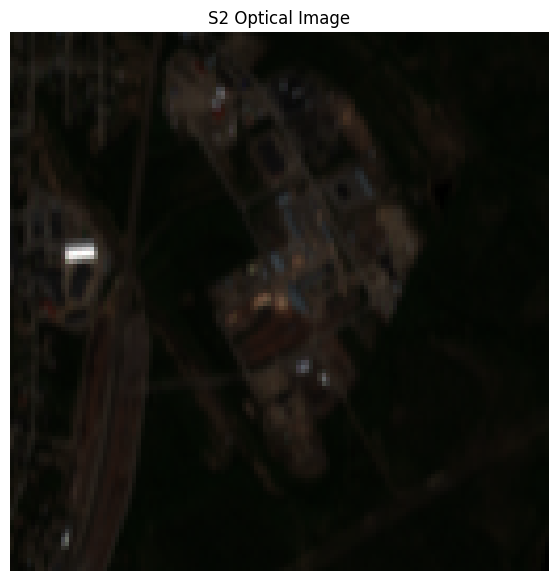

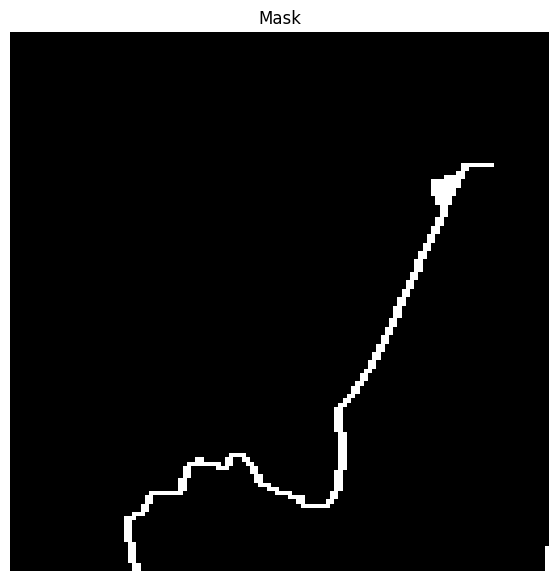

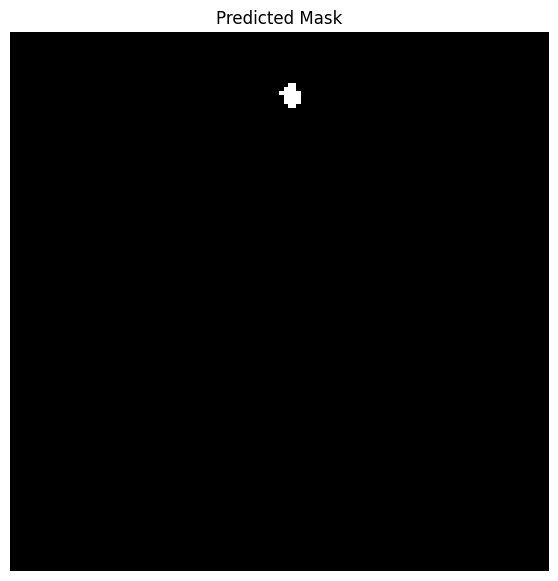

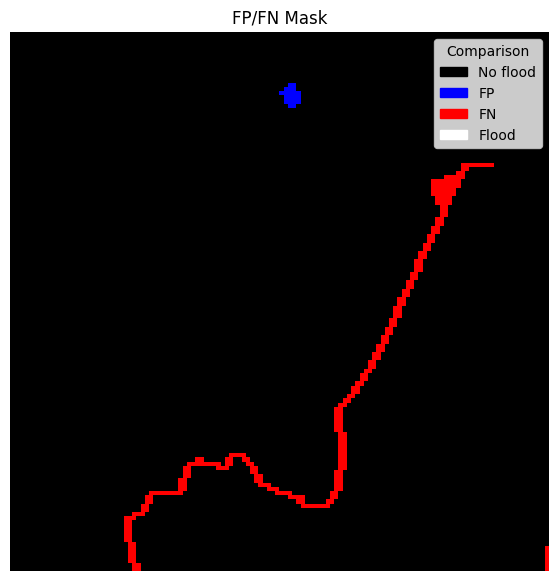

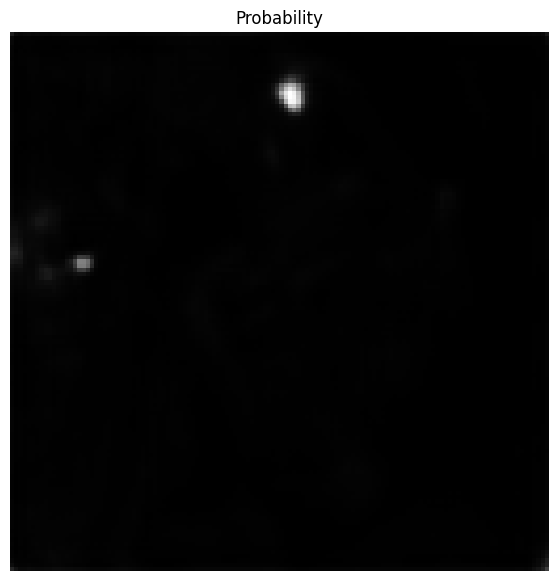

id: torch.Size([1])
sample_id: EMSR470_AOI01_46_07_2_1.tif
image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR470_AOI01_46_07_2_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_46_07_2_1.tif
accuracy: 0.966552734375
precision: 0.9006609916687012
recall: 0.9954080581665039
f1: 0.9456672072410583
iou: 0.8969343900680542


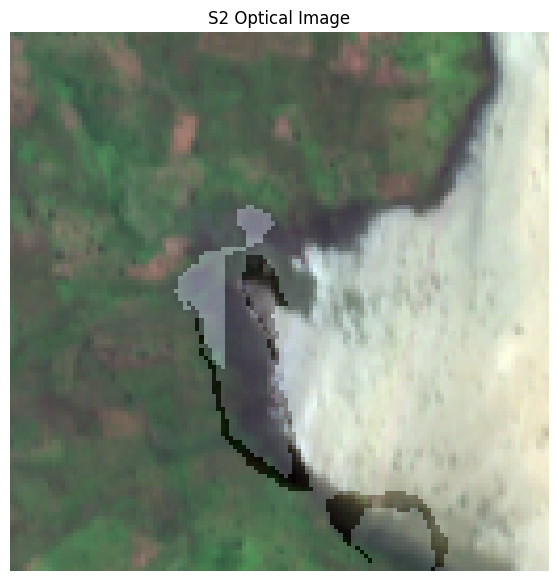

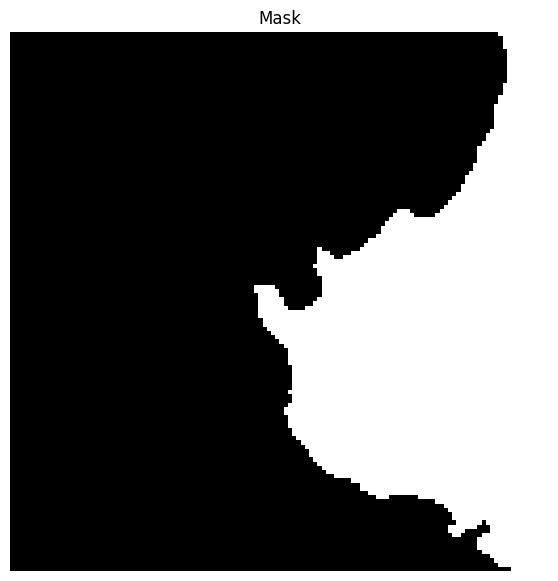

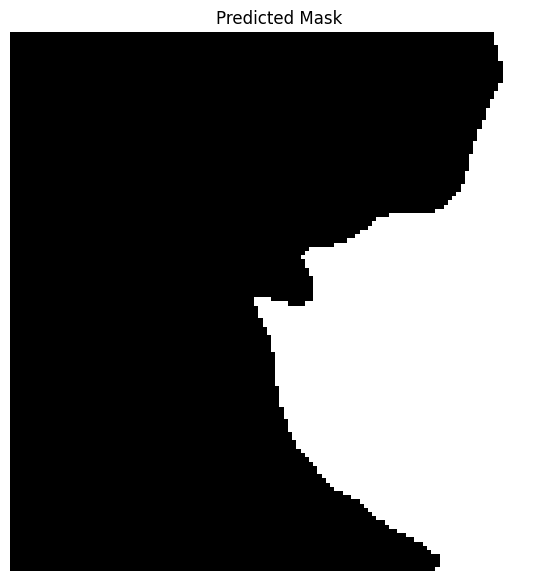

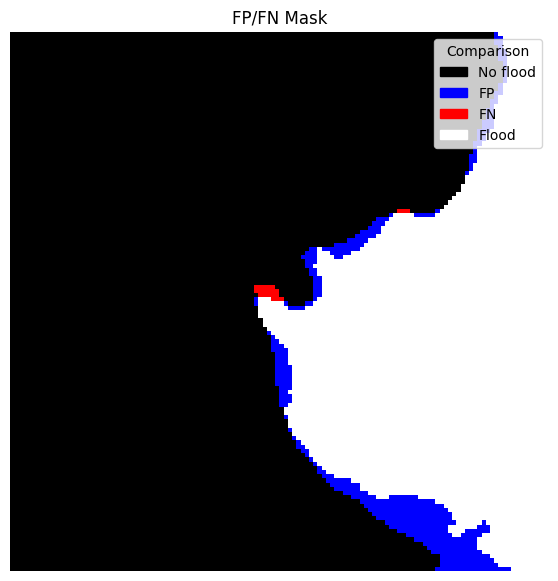

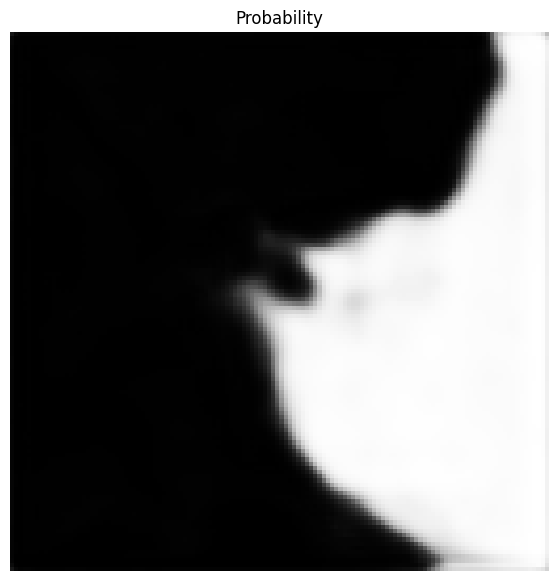

id: torch.Size([1])
sample_id: EMSR570_AOI02_07_03_2_1.tif
image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR570_AOI02_07_03_2_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR570_AOI02_07_03_2_1.tif
accuracy: 0.8184814453125
precision: 0.886956512928009
recall: 0.7316717505455017
f1: 0.8018653392791748
iou: 0.6692615747451782


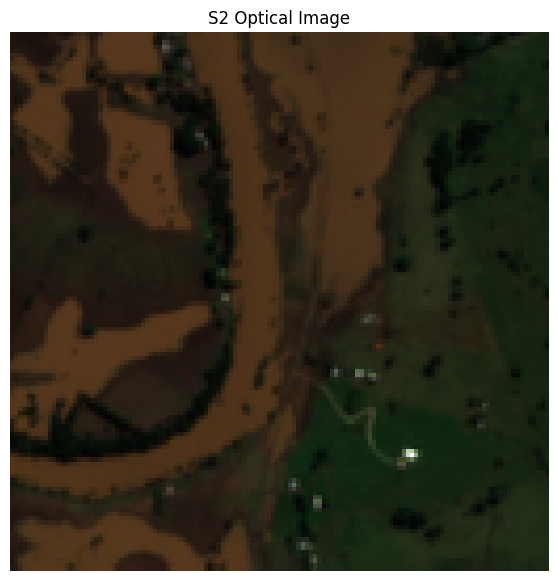

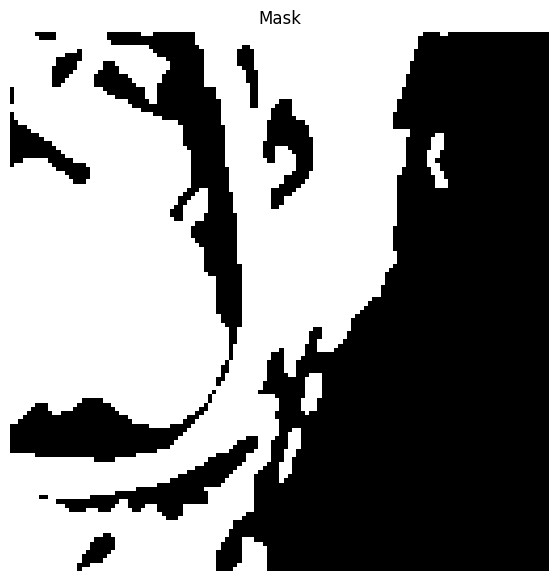

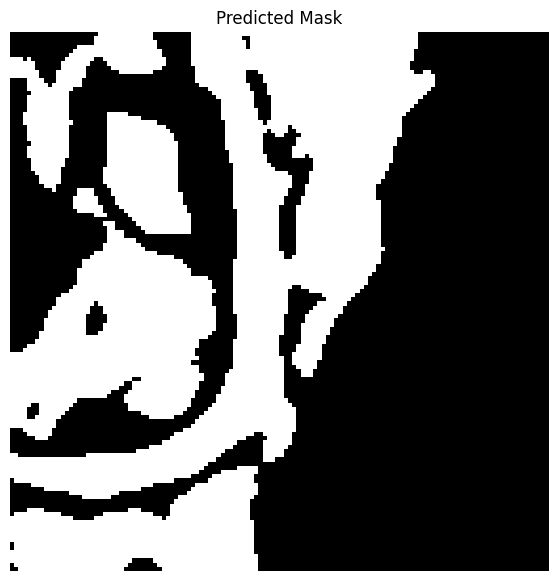

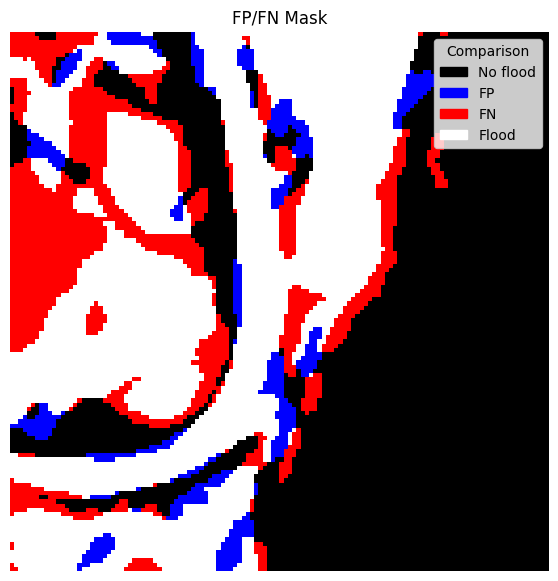

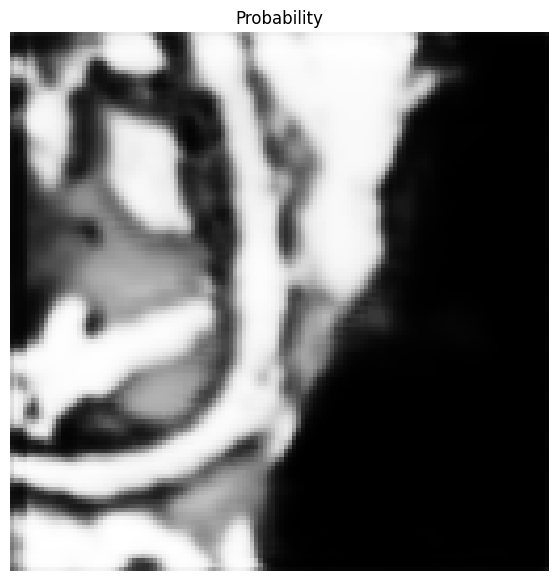

In [ ]:
plot.plot_s2_results(results)

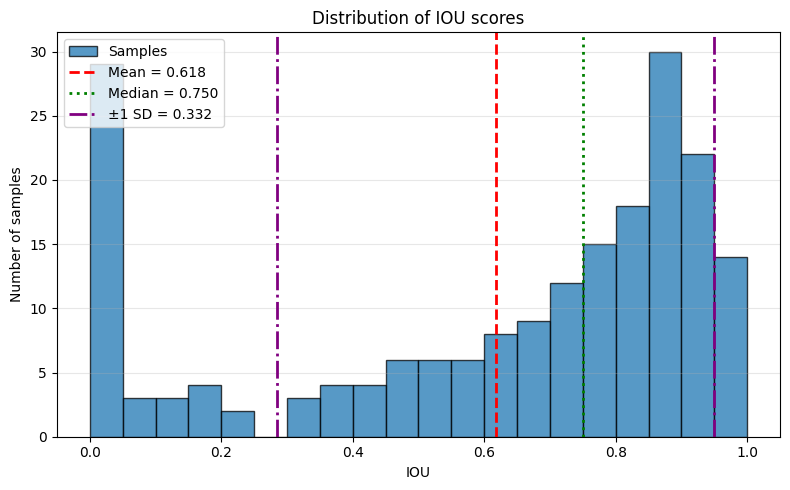

In [6]:
plot.plot_metric_distribution_from_csv(cfg.S2_TEST_RESULTS_CSV)

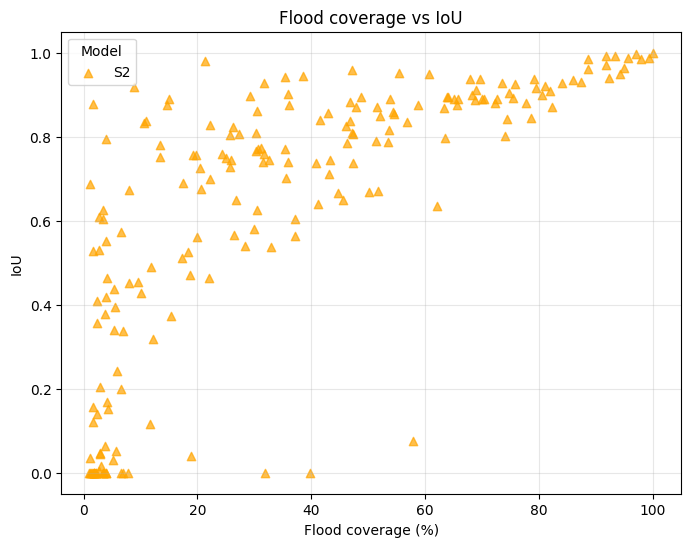

In [7]:
plot.plot_iou_vs_flood_scatter([cfg.S2_TEST_RESULTS_CSV])

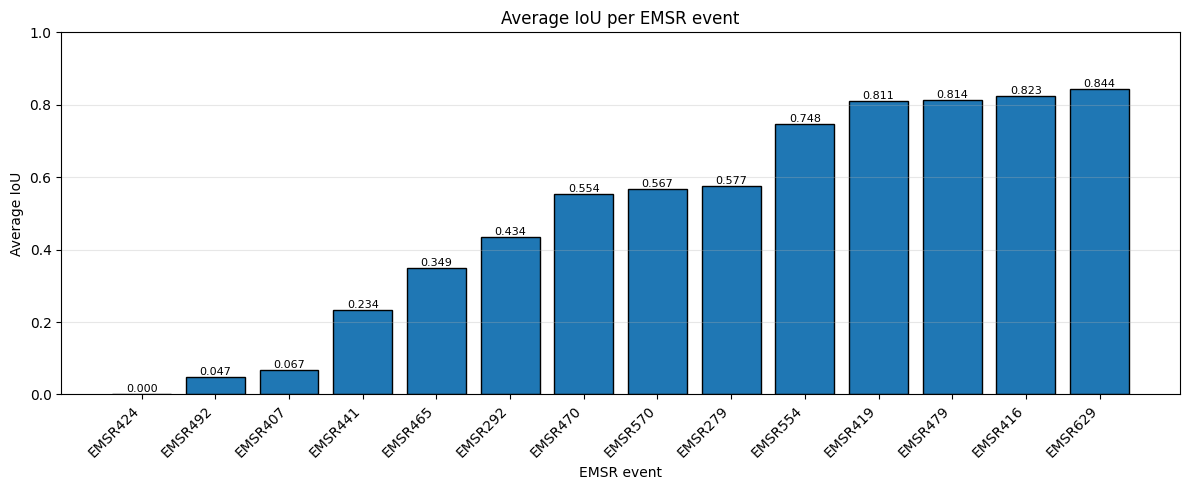

,event_id,mean_iou
5,EMSR424,0.000000
10,EMSR492,0.047431
2,EMSR407,0.066824
6,EMSR441,0.234482
7,EMSR465,0.349124
1,EMSR292,0.434113
8,EMSR470,0.554045
12,EMSR570,0.567411
0,EMSR279,0.576595
11,EMSR554,0.747642


In [8]:
plot.plot_average_iou_per_event(cfg.S2_TEST_RESULTS_CSV)

In [9]:
import src.inference.inference as inference

samples = ["EMSR407_AOI01_03_17_2_1.tif",
           "EMSR470_AOI01_29_13_2_2.tif",
           "EMSR470_AOI01_10_25_1_1.tif",
           "EMSR470_AOI01_47_10_1_2.tif",
           "EMSR629_AOI01_08_02_1_1.tif",
           "EMSR629_AOI01_09_01_1_2.tif"
]


results = inference.inference(cfg, cfg.S2_MODEL, samples)

Model directory: /content/drive/MyDrive/MSc/Flood-Mapping/experiments/STURM-fusion-24/Sentinel2_Optical/lr_0.001/bs_64/wd_1e-05/dr_0.2


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


id: torch.Size([1])
sample_id: EMSR407_AOI01_03_17_2_1.tif
image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR407_AOI01_03_17_2_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR407_AOI01_03_17_2_1.tif
accuracy: 0.95257568359375
precision: 0.04109589010477066
recall: 0.023575639352202415
f1: 0.02996250055730343
iou: 0.015209125354886055


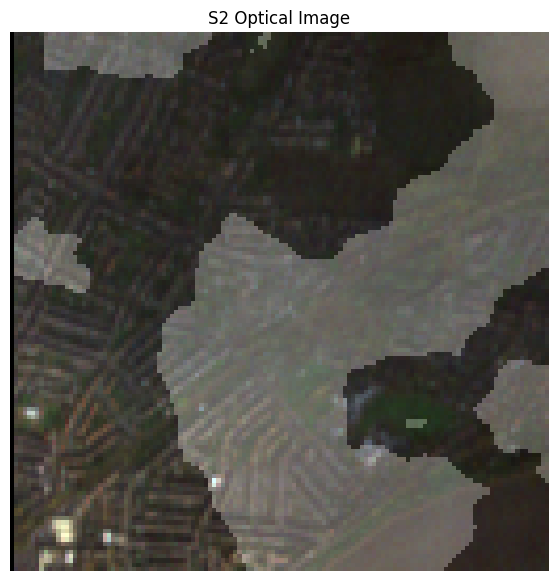

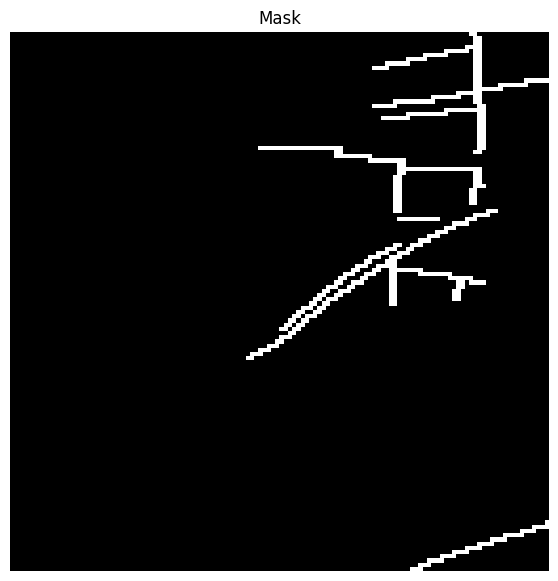

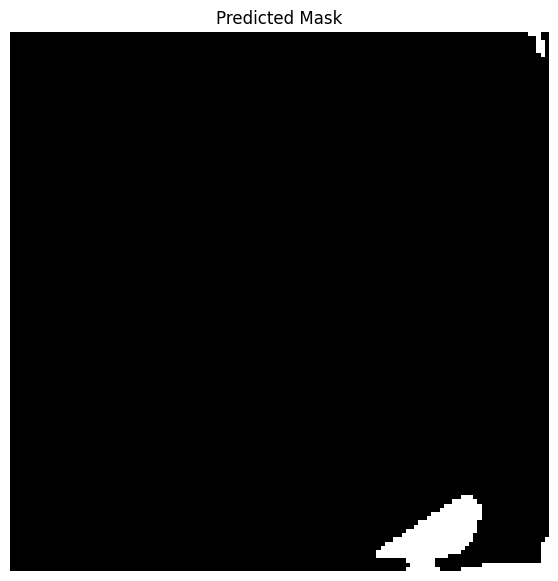

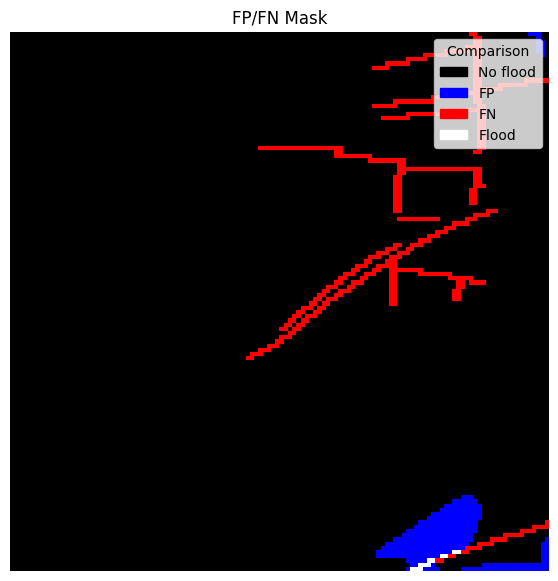

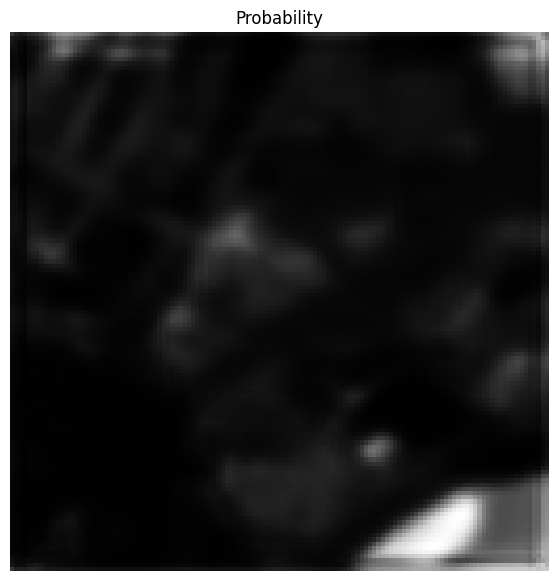

id: torch.Size([1])
sample_id: EMSR470_AOI01_10_25_1_1.tif
image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR470_AOI01_10_25_1_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_10_25_1_1.tif
accuracy: 0.84429931640625
precision: 0.7700205445289612
recall: 0.6444683074951172
f1: 0.7016723155975342
iou: 0.5404431819915771


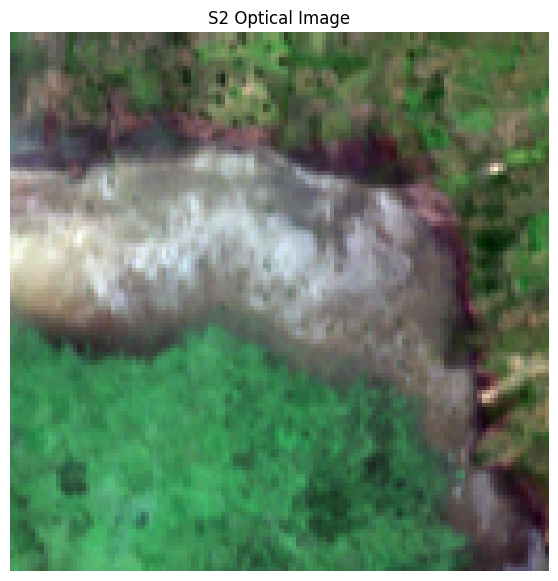

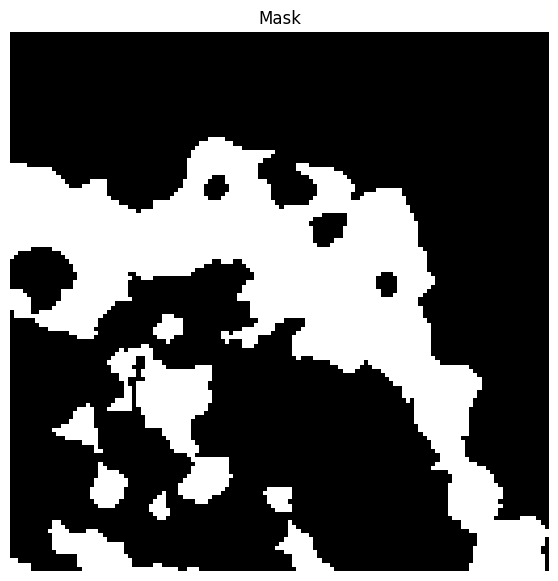

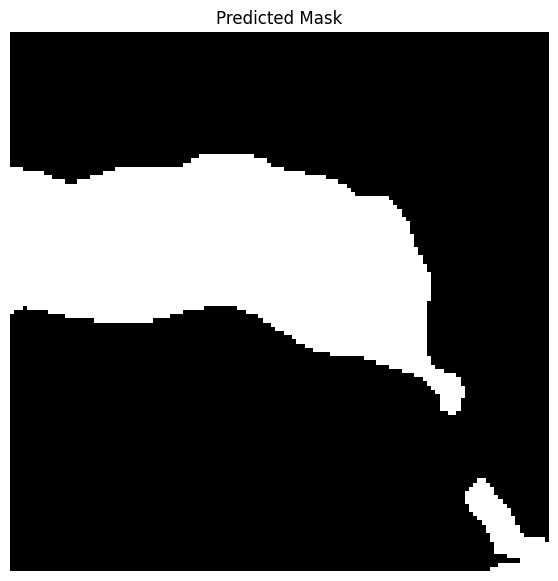

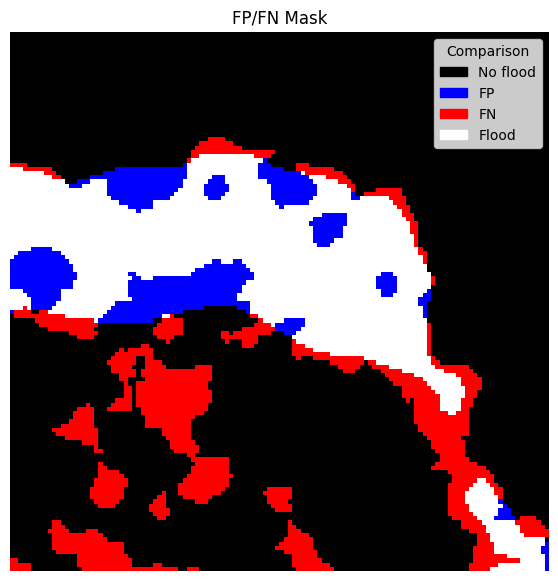

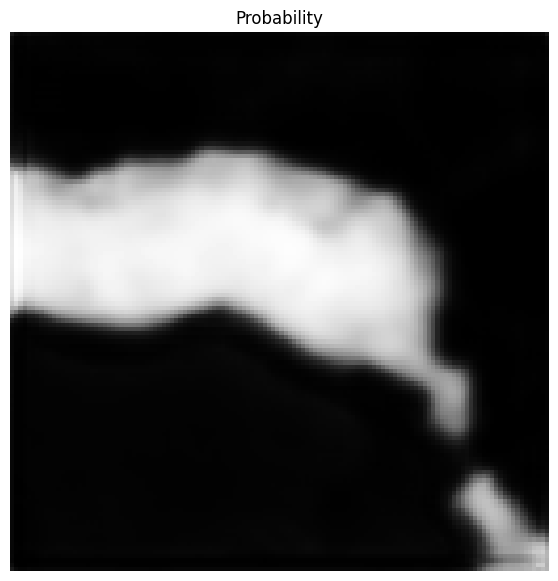

id: torch.Size([1])
sample_id: EMSR470_AOI01_29_13_2_2.tif
image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR470_AOI01_29_13_2_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_29_13_2_2.tif
accuracy: 0.97296142578125
precision: 0.9686040282249451
recall: 0.9830209612846375
f1: 0.9757591485977173
iou: 0.9526658654212952


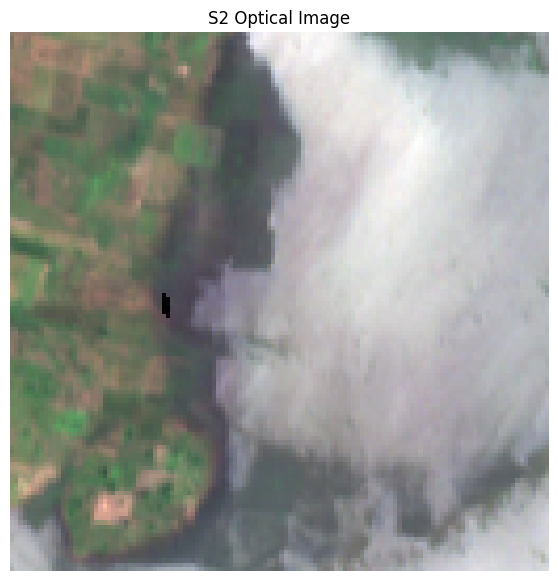

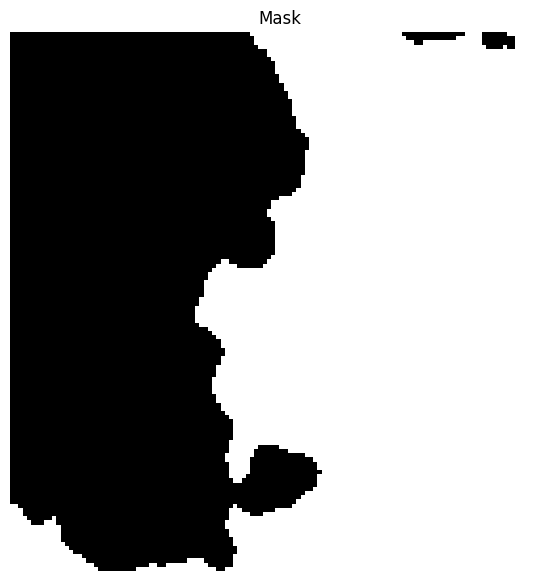

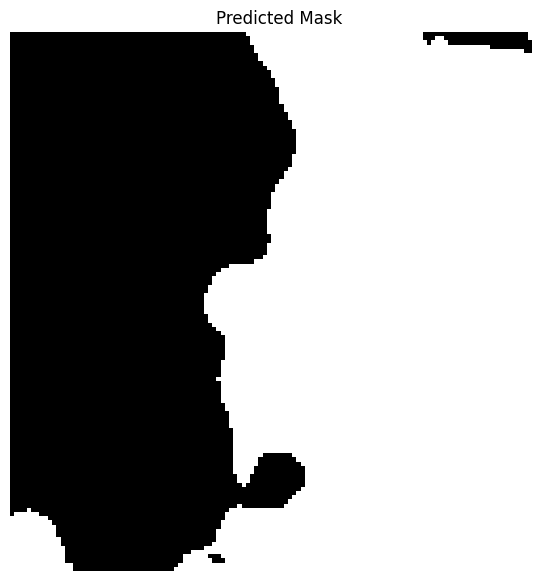

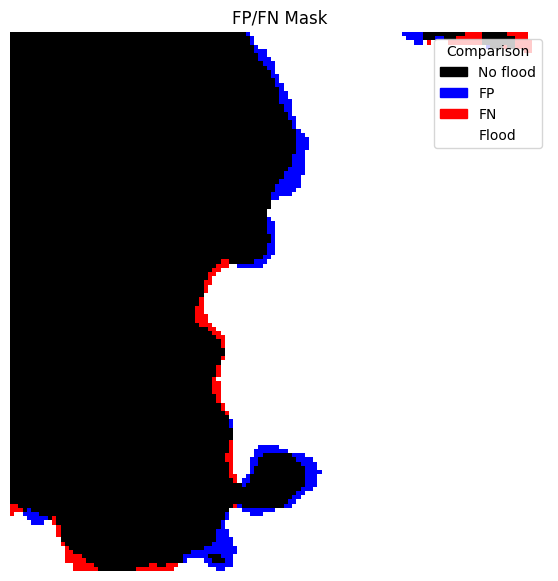

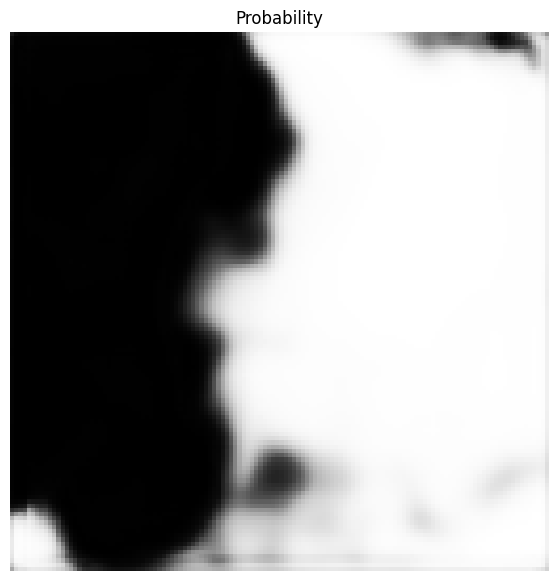

id: torch.Size([1])
sample_id: EMSR470_AOI01_47_10_1_2.tif
image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR470_AOI01_47_10_1_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_47_10_1_2.tif
accuracy: 0.8714599609375
precision: 0.4757045805454254
recall: 0.4880358874797821
f1: 0.48179128766059875
iou: 0.31734198331832886


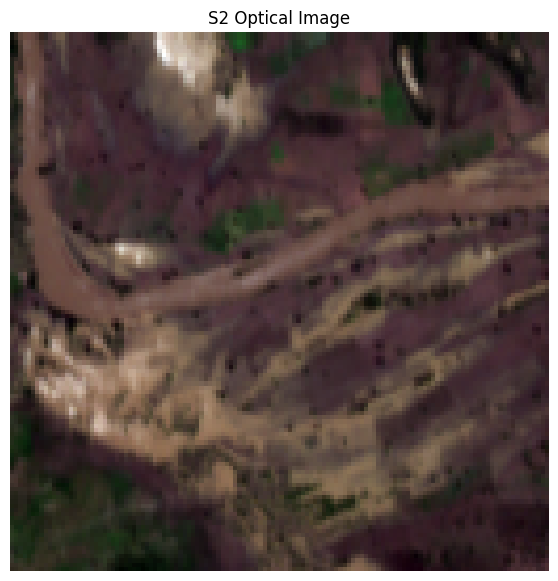

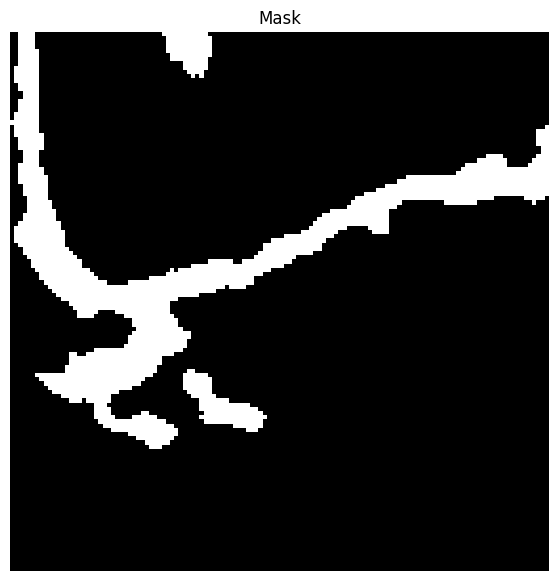

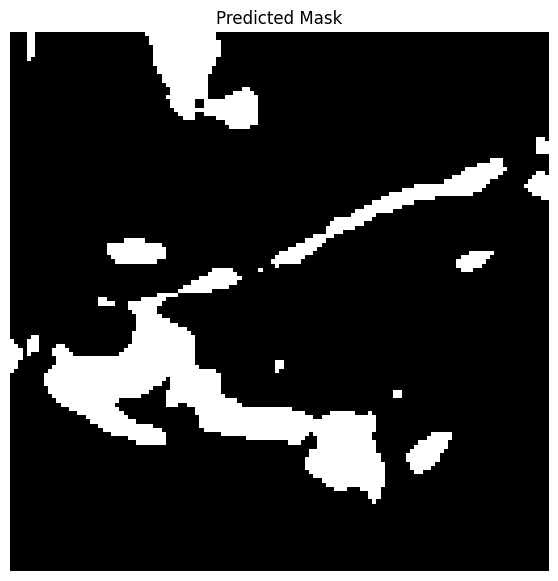

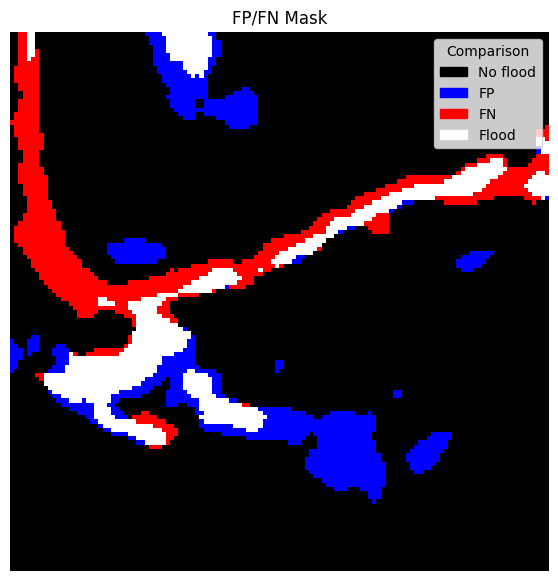

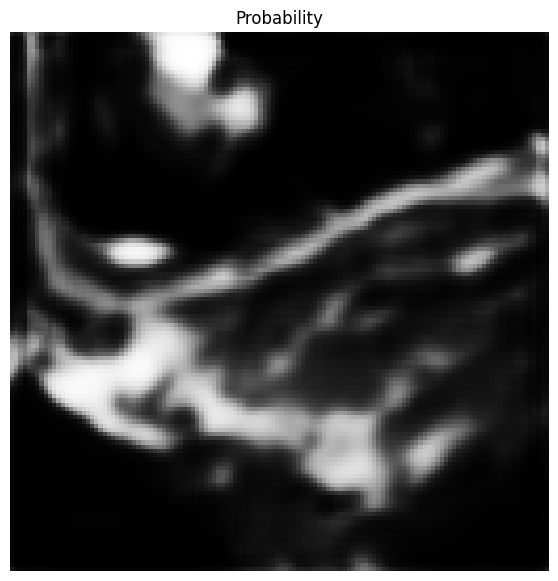

id: torch.Size([1])
sample_id: EMSR629_AOI01_08_02_1_1.tif
image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR629_AOI01_08_02_1_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR629_AOI01_08_02_1_1.tif
accuracy: 0.96307373046875
precision: 0.9633647203445435
recall: 0.9990999698638916
f1: 0.9809069037437439
iou: 0.9625294208526611


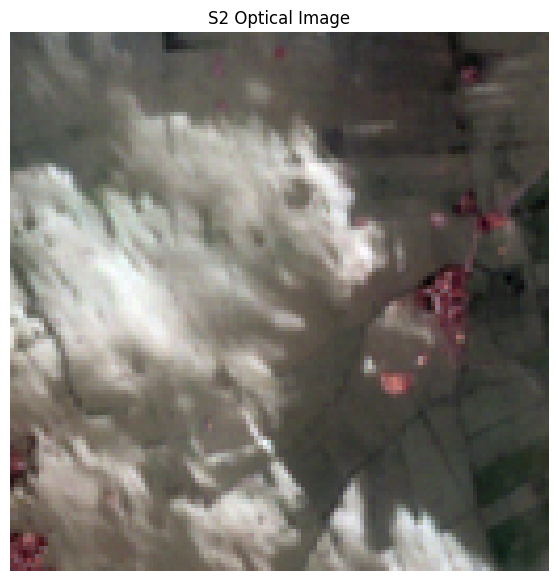

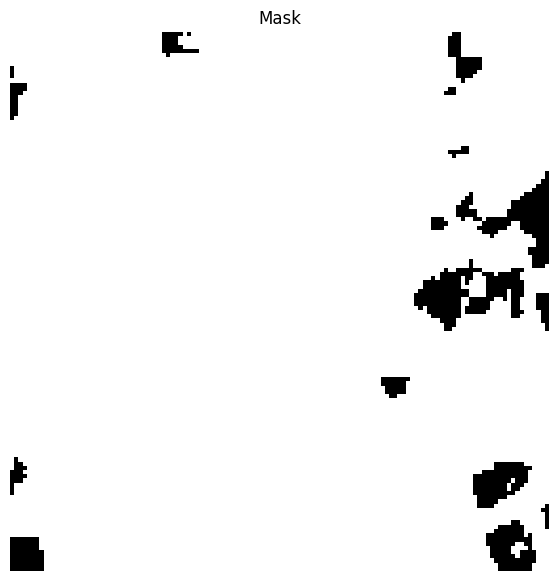

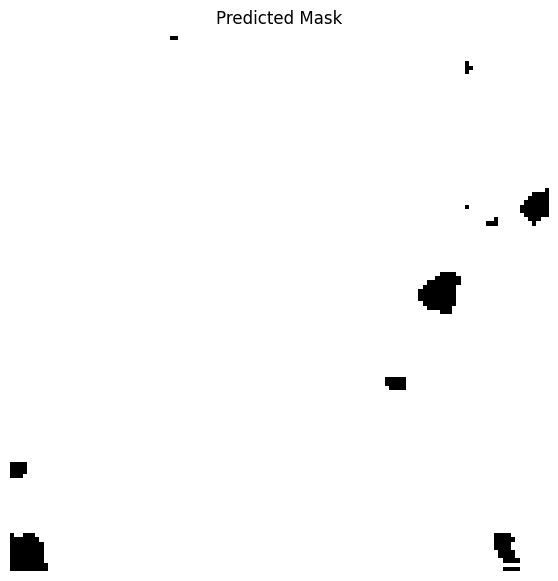

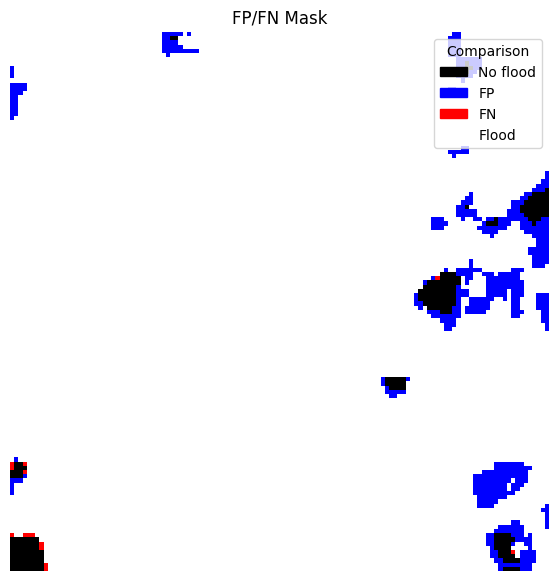

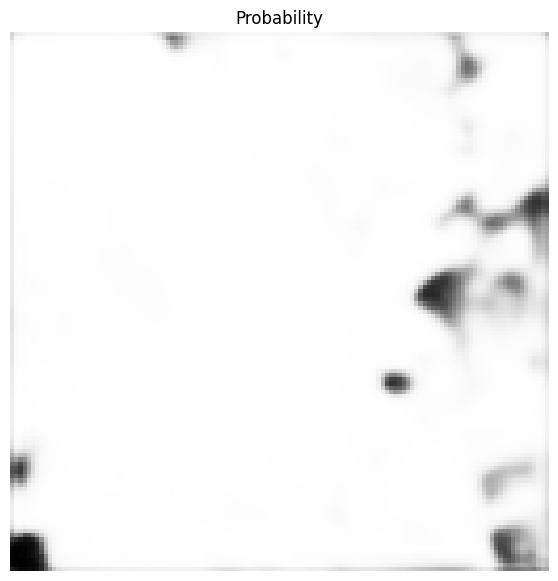

id: torch.Size([1])
sample_id: EMSR629_AOI01_09_01_1_2.tif
image: torch.Size([1, 9, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S2/EMSR629_AOI01_09_01_1_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR629_AOI01_09_01_1_2.tif
accuracy: 0.98565673828125
precision: 0.9866921305656433
recall: 0.9988150000572205
f1: 0.9927165508270264
iou: 0.9855384826660156


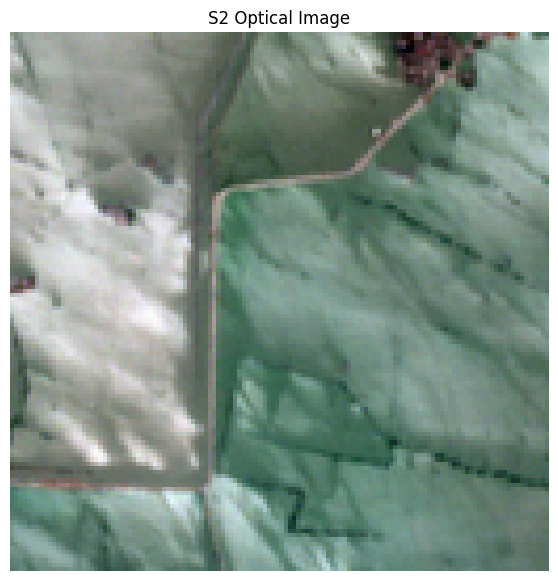

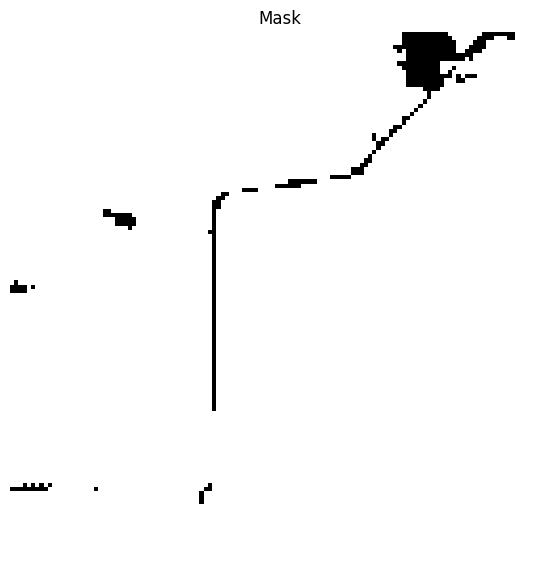

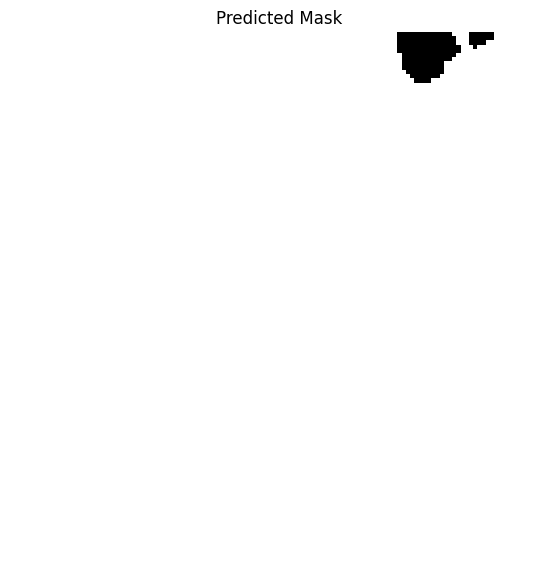

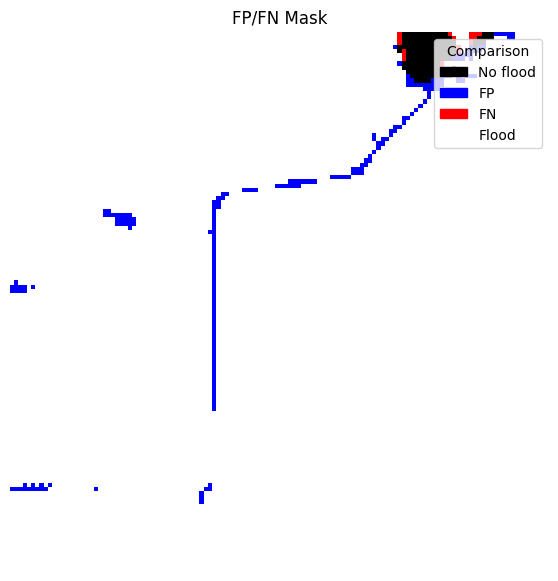

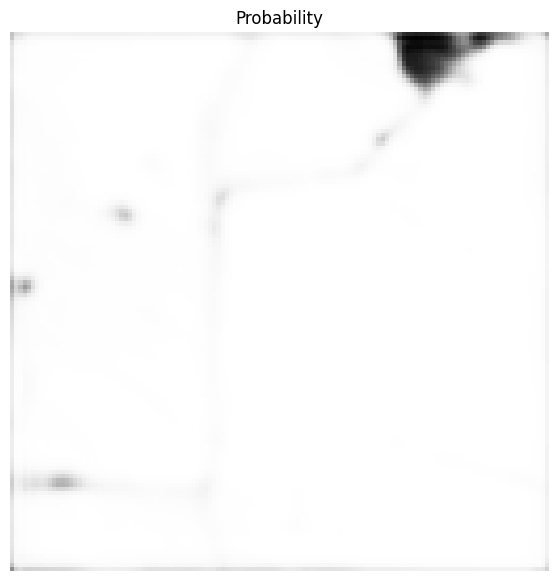

In [10]:
plot.plot_s2_results(results)